In [18]:
# pip install google-genai
from google import genai
client = genai.Client()

In [ ]:
# Test gemini
model = "gemini-flash-latest"
try:
    response = client.models.generate_content(
        model=model,
        contents="Invent an original joke that non-English speakers could understand"
        # contents="תמציא בדיחה מקורית"
    )
    print(response.text)
except genai.errors.ServerError as err:
    print(f"Model {model} error: {err}")

To make a joke understandable for non-English speakers, it should rely on **situational irony** rather than wordplay or puns.

Here is an original joke designed to be simple and universal:

***

### The Invisible Umbrella

A man walks into a shop and buys a very expensive **"Invisible Umbrella."**

The shopkeeper says, "This is the best umbrella in the world! You will never be wet again."

The next day, it rains very hard. The man walks down the street, and he is completely soaked from head to toe. He is dripping water everywhere.

He runs back to the shop, angry and wet. He yells at the shopkeeper, "Look at me! I am covered in water! Your 'Invisible Umbrella' does not work!"

The shopkeeper looks at the man and says: 

**"Of course it works! But how do you know you are holding it?"**

***

### Why this works for non-English speakers:
1.  **Simple Vocabulary:** It uses basic words (shop, rain, water, wet, invisible).
2.  **No Puns:** The humor doesn't depend on English grammar or doubl

In [5]:
import json, logging
import networkx as nx
logger = logging.getLogger("gemini")

In [ ]:
def text_to_utilities(natural_language_description:str)->dict:
    """
    This function uses AI to extract reasonable utility values 
    from a natural-language description of preferences.
    """
    contents = f"""
        הנה תיאור של העדפות בין שלוש משמרות: בוקר, צהריים וערב. 
        לפי התיאור המילולי, עליך לתת לכל משמרת ערך מספרי כלשהו בין 0 ל-100 המתאר את רמת ההעדפה.
        תחזיר את התשובה בפורמט JSON 
        בתוך סוגריים מסולסלים בלי שום תוספות.
        ---
        '{natural_language_description}'
        """
    try:
        response = client.models.generate_content(
            model=model,
            contents=contents
        )
        logger.debug("Response text: %s", response.text)
        utils = json.loads(response.text) 
        logger.debug("Response struct: %s", utils)
        return utils
    except genai.errors.ServerError as err:
        logger.error(f"Model {model} error: {err}")


In [7]:
logger.handlers = [logging.StreamHandler()]
logger.setLevel(logging.DEBUG)

In [8]:
# Test text_to_utilities
utils1 = text_to_utilities("בבוקר מאד לא נוח לי. בצהריים אפשרי. בערב הכי נוח.")
print(utils1)

Response text: {
  "בוקר": 10,
  "צהריים": 50,
  "ערב": 100
}
Response struct: {'בוקר': 10, 'צהריים': 50, 'ערב': 100}


{'בוקר': 10, 'צהריים': 50, 'ערב': 100}


In [9]:
utils = dict()
utils["אבי"] = utils1
utils["בני"] = text_to_utilities("בבוקר אידיאלי. בצהריים בסדר. בערב הכי פחות טוב.")
utils["גדי"] = text_to_utilities("הכי מתאים לי בצהריים. בוקר גם בסדר. ערב ככה ככה.")
print(utils)

Response text: {
  "בוקר": 100,
  "צהריים": 60,
  "ערב": 20
}
Response struct: {'בוקר': 100, 'צהריים': 60, 'ערב': 20}
Response text: {
  "בוקר": 75,
  "צהריים": 100,
  "ערב": 50
}
Response struct: {'בוקר': 75, 'צהריים': 100, 'ערב': 50}


{'אבי': {'בוקר': 10, 'צהריים': 50, 'ערב': 100}, 'בני': {'בוקר': 100, 'צהריים': 60, 'ערב': 20}, 'גדי': {'בוקר': 75, 'צהריים': 100, 'ערב': 50}}


In [10]:
def dicts_to_graph(map_person_to_utility_dict: dict[dict])->nx.Graph:
    """
    Generates a weighted bipartite graph that describes the utilities people assign to objects.

    >>> G = dicts_to_graph({"avi":{"x":50,"y":70}, "beni":{"x":30,"y":40}})
    >>> list(G.edges)
    [('avi', 'x'), ('avi', 'y'), ('x', 'beni'), ('y', 'beni')]
    """
    result = nx.Graph()
    for person,map_object_to_utility in map_person_to_utility_dict.items():
        for object,utility in map_object_to_utility.items():
            result.add_edge(person, object, weight=utility)
    return result

G = dicts_to_graph(utils)
print(list(G.edges))

[('אבי', 'בוקר'), ('אבי', 'צהריים'), ('אבי', 'ערב'), ('בוקר', 'בני'), ('בוקר', 'גדי'), ('צהריים', 'בני'), ('צהריים', 'גדי'), ('ערב', 'בני'), ('ערב', 'גדי')]


In [11]:
draw_options = {
    "font_size": 10,
    "node_size": 700,
    "node_color": "yellow",
    "edgecolors": "black",
    "linewidths": 1,
    "width": 1,
    "with_labels": True
}

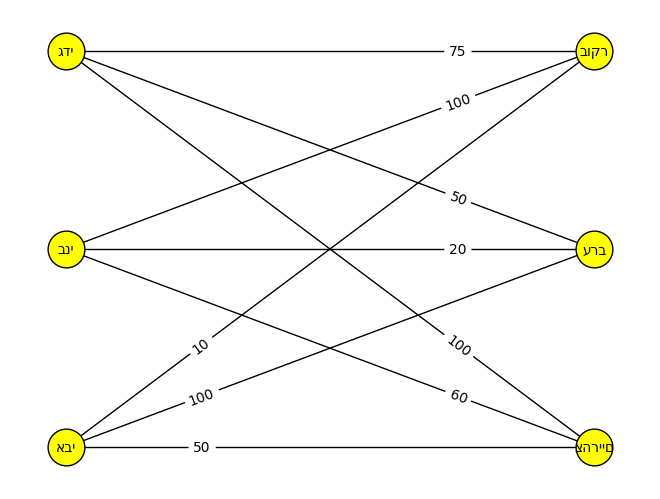

In [14]:
people = utils.keys()
layout = nx.bipartite_layout(G, people)
nx.draw(G,  **draw_options, pos=layout)
nx.draw_networkx_edge_labels(G, layout, edge_labels=nx.get_edge_attributes(G,'weight'), label_pos=0.25);

In [16]:
max_weight_matching = nx.max_weight_matching(G) 
print(max_weight_matching)
sorted_matching = {
    (x,y) if x in people else (y,x)
    for x,y in max_weight_matching
}
print(sorted_matching)
# max_weight_matching_graph = nx.Graph(max_weight_matching)
# nx.draw(max_weight_matching_graph,  **draw_options, pos=layout)
# nx.draw_networkx_edge_labels(max_weight_matching_graph, layout, edge_labels=nx.get_edge_attributes(my_graph,'weight'));

{('ערב', 'אבי'), ('גדי', 'צהריים'), ('בני', 'בוקר')}
{('אבי', 'ערב'), ('גדי', 'צהריים'), ('בני', 'בוקר')}


In [ ]:
def matching_to_text(matching:set[tuple[str]])->str:
    """
    This function uses AI to present the given matching (a set of pairs)
         in natural language.
    """
    
    contents = f"""
        נתון שידוך מושלם בין אנשים לבין משמרות.
        צריך להודיע לאנשים איזה משמרות הם עושים.
        נסח הודעה המודיעה לכל אחד איזה משמרת הוא עושה, בסגנון של מפקד בצבא.
        ---
        '{sorted_matching}'
        """
    try:
        response = client.models.generate_content(
            model=model,
            contents=contents
        )
        logger.debug("Response text: %s", response.text)
        return response.text
    except genai.errors.ServerError as err:
        logger.error(f"Model {model} error: {err}")

print(matching_to_text(sorted_matching))

Response text: להלן נוסח ההודעה בסגנון פיקודי:

---

**חיילים, להקשיב!**

להלן שיבוץ המשמרות הרשמי. אני מצפה מכל אחד מכם להתייצב בזמן, בציוד מלא ובמוכנות שיא. אין איחורים, אין תירוצים – ביצוע פקודה מלא.

**אלה הגזרות שלכם:**

*   **בני –** אתה תופס את משמרת ה**בוקר**.
*   **גדי –** אתה על משמרת ה**צהריים**.
*   **אבי –** אתה סוגר את משמרת ה**ערב**.

אני מצפה לעבודה מקצועית וחדה. מי שמאחר – מסתבך איתי. 

**צאו לביצוע. רות, סוף!**


להלן נוסח ההודעה בסגנון פיקודי:

---

**חיילים, להקשיב!**

להלן שיבוץ המשמרות הרשמי. אני מצפה מכל אחד מכם להתייצב בזמן, בציוד מלא ובמוכנות שיא. אין איחורים, אין תירוצים – ביצוע פקודה מלא.

**אלה הגזרות שלכם:**

*   **בני –** אתה תופס את משמרת ה**בוקר**.
*   **גדי –** אתה על משמרת ה**צהריים**.
*   **אבי –** אתה סוגר את משמרת ה**ערב**.

אני מצפה לעבודה מקצועית וחדה. מי שמאחר – מסתבך איתי. 

**צאו לביצוע. רות, סוף!**
